<a href="https://colab.research.google.com/github/yaozin/Exercicios/blob/main/Titanic_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conectar ao github

In [ ]:
import os
from google.colab import userdata

# Configure seu nome e email (obrigatório) usando os segredos
# Certifique-se de que 'GITHUB_USER_EMAIL' e 'GITHUB_USERNAME' estejam configurados nos Colab Secrets
!git config --global user.email "{userdata.get('UserEmail')}"
!git config --global user.name "{userdata.get('GITHUB_USERNAME')}"

# Os valores de TOKEN, USER (username) e REPO serão definidos na célula seguinte a partir dos segredos.

In [ ]:
# Importa a biblioteca para acessar os segredos
from google.colab import userdata

# Recupera o token, usuário (username) e email do GitHub do Colab Secrets
TOKEN = userdata.get('GitToken')
USER = userdata.get('GITHUB_USERNAME') # Use o nome de usuário do GitHub aqui
USER_EMAIL = userdata.get('UserEmail') # Para o git config user.email
REPO = "Exercicios"

# Define a URL com o token para autenticação automática
repo_url = f"https://{TOKEN}@github.com/{USER}/{REPO}.git"

print("Token e Usuário carregados com sucesso do Colab Secrets!")

Token e Usuário carregados com sucesso do Colab Secrets!


In [ ]:
# Clona o repositório para o ambiente do Colab
!git clone {repo_url}

# Entra na pasta do repositório
%cd {REPO}

# Adiciona as mudanças recentes (todos os arquivos modificados no repositório)
!git add .

# Faz o commit das mudanças com uma mensagem descritiva
!git commit -m "Novas transformações e limpeza de dados (após manipulação de nomes e idades)"

# Faz o push para o GitHub, usando a URL do repositório configurada anteriormente
!git push {repo_url} main

fatal: destination path 'Exercicios' already exists and is not an empty directory.
/content/Exercicios
hint: You've added another git repository inside your current repository.
hint: Clones of the outer repository will not contain the contents of
hint: the embedded repository and will not know how to obtain it.
hint: If you meant to add a submodule, use:
hint: 
hint: 	git submodule add <url> Exercicios
hint: 
hint: If you added this path by mistake, you can remove it from the
hint: index with:
hint: 
hint: 	git rm --cached Exercicios
hint: 
hint: See "git help submodule" for more information.
[main 42c656a] Novas transformações e limpeza de dados (após manipulação de nomes e idades)
 1 file changed, 1 insertion(+)
 create mode 160000 Exercicios
To https://github.com/yaozin/Exercicios.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/yaozin/Exercicios.git'
hint: Updates were rejected because the remote contains work that you do
hi

# ANALISE EXPLORATORIA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dadosBrutos = pd.read_csv('/content/drive/MyDrive/Data science/Projeto - DataAnalytics/Exercicios/Titanic-Dataset.csv')
dadosBrutos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Classificação de Variáveis:
As colunas Age (idade - quantitativa discreta), Fare (tarifa - Quantitativa contínua), Pclass (classe qualitativa ordinal) e Survived (qualitativa nominal - binario) pertencem a quais tipos de variáveis (quantitativa contínua, discreta, qualitativa nominal ou ordinal)?

In [ ]:
dadosBrutos.shape

(891, 12)

In [ ]:
dadosBrutos.info()
#CAbine e idade são colunas com valores faltando

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
dadosBrutos.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [ ]:
idDuplicados = dadosBrutos.duplicated(subset='PassengerId')
idDuplicados.sum()
#zero Ids duplicados
nomeDuplicados = dadosBrutos.duplicated(subset='Name')
nomeDuplicados.sum()
#zero nomes duplicados

np.int64(0)

Definição de População e Amostra: É necessário entender se os dados representam o conjunto completo de elementos ou apenas um subconjunto para inferência



1.   Titanic teve um total de 2.224 passageiros totais, essa é a população
2.   Nosso dataset em 891 registros, com sobreviventes e falecidos. Essa é nossa amostra



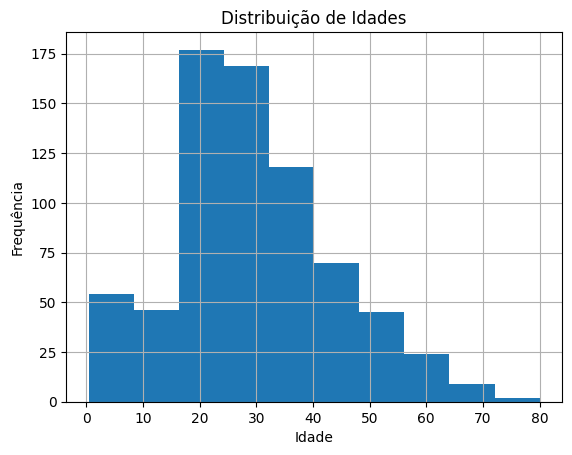

In [ ]:
idadesnulas = dadosBrutos['Age'].isnull()
idadesnulas.sum()

dadosBrutos.Age.hist(bins=10)
plt.title('Distribuição de Idades')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()
#Distribuição assimétrica - levemente positiva - usar mediana

In [ ]:
idademediana = dadosBrutos.Age.median()
dadosBrutos.Age.fillna(idademediana, inplace=True)
dadosBrutos.Age.isnull().sum()
dadosBrutos['Age']=dadosBrutos.Age.astype(int)
dadosBrutos.tail()

/tmp/ipykernel_968/3820317586.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dadosBrutos.Age.fillna(idademediana, inplace=True)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32,0,0,370376,7.75,NaN,Q


In [ ]:
dadosBrutos.Sex.value_counts()
dadosBrutos.Sex=dadosBrutos.Sex.str.upper()
dadosBrutos.head(10)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",MALE,22,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",FEMALE,38,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",FEMALE,26,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",FEMALE,35,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",MALE,35,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",MALE,28,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",MALE,54,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",MALE,2,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",FEMALE,27,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",FEMALE,14,1,0,237736,30.0708,NaN,C


In [ ]:
#Tratar coluna SibSP
dadosBrutos.SibSp.value_counts()
dadosBrutos['Siblings_Spouses'] = dadosBrutos.SibSp
dadosBrutos.drop(columns='SibSp', inplace=True)
dadosBrutos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Parch,Ticket,Fare,Cabin,Embarked,Siblings_Spouses
0,1,0,3,"Braund, Mr. Owen Harris",MALE,22,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",FEMALE,38,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",FEMALE,26,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",FEMALE,35,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",MALE,35,0,373450,8.0500,NaN,S,0


In [ ]:
#Tratar Name
dadosBrutos['NameDuo'] = dadosBrutos.Name
dadosBrutos.drop(columns='NameDuo', inplace=True)
dadosBrutos['NameSolteira'] = dadosBrutos['Name'].str.extract(r'\((.*)\)')
dadosBrutos.head()
dadosBrutos['LastName'] = dadosBrutos['Name'].str.extract(r'([A-Za-z]+),')
dadosBrutos.Name= dadosBrutos.Name.str.replace(r'\(.*\)', '', regex=True).str.strip()
dadosBrutos.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Parch,Ticket,Fare,Cabin,Embarked,Siblings_Spouses,NameSolteira,LastName
0,1,0,3,"Braund, Mr. Owen Harris",MALE,22,0,A/5 21171,7.2500,NaN,S,1,NaN,Braund
1,2,1,1,"Cumings, Mrs. John Bradley",FEMALE,38,0,PC 17599,71.2833,C85,C,1,Florence Briggs Thayer,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",FEMALE,26,0,STON/O2. 3101282,7.9250,NaN,S,0,NaN,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath",FEMALE,35,0,113803,53.1000,C123,S,1,Lily May Peel,Futrelle
4,5,0,3,"Allen, Mr. William Henry",MALE,35,0,373450,8.0500,NaN,S,0,NaN,Allen


In [ ]:
dadosBrutos.Ticket.value_counts()

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


# Medidas de pontos centrais

**Ao analisar a coluna Age, por que o manual sugere que a mediana é mais robusta que a média em casos de assimetria ou presença de outliers? **- *Com poucos valores altos, a média é superestimada ou subestimada, já com a mediana, ela é a posição central dos valores ordenados*

In [ ]:
Q1_fare = dadosBrutos.Fare.quantile(0.25)
Q3_fare = dadosBrutos.Fare.quantile(0.75)

In [ ]:
IQR_fare = Q3_fare - Q1_fare
limite_superior_fare = Q3_fare + 1.5 * IQR_fare
limite_inferior_fare = Q1_fare - 1.5 * IQR_fare
print(f"Limite Superior: {limite_superior_fare}")
print(f"Limite Inferior: {limite_inferior_fare}")

Limite Superior: 65.6344
Limite Inferior: -26.724


In [ ]:
import plotly.express as px
boxFare = px.box(dadosBrutos, y='Fare')
boxFare.show()

Mean Survival Rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


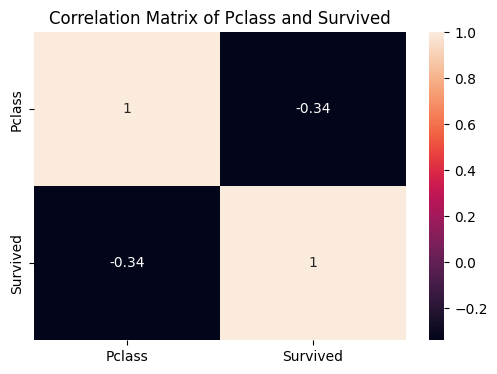

In [ ]:
Pclass_survived = dadosBrutos.groupby('Pclass')['Survived'].mean()
print('Mean Survival Rate by Pclass:')
print(Pclass_survived)

# Para usar sns.heatmap para correlação, precisamos de uma matriz de correlação.
# Vamos calcular a correlação entre Pclass e Survived diretamente do DataFrame original.
correlation_matrix = dadosBrutos[['Pclass', 'Survived']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix, annot=True)
plt.title('Correlation Matrix of Pclass and Survived')
plt.show()

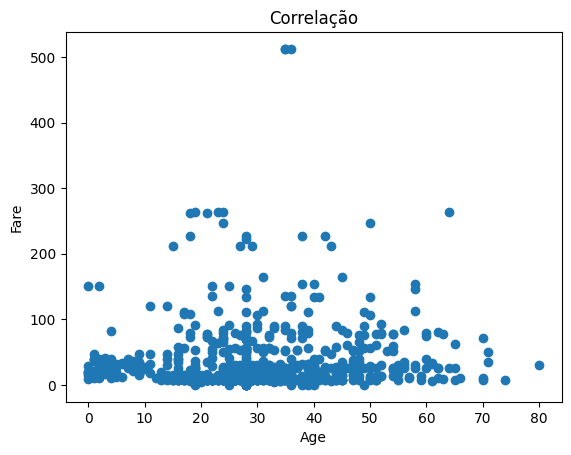

In [ ]:
plt.scatter(dadosBrutos.Age, dadosBrutos.Fare)
plt.title('Correlação')
plt.ylabel('Fare')
plt.xlabel('Age')
plt.show()

In [12]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [20]:
!git add Titanic_Projeto.ipynb
!git commit -m "Agora sim com as 10 novas células"
!git push {repo_url} main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date
